# Recommender system
## Project Overview
This project focuses on the development and evaluation of various Recommender System architectures using the [MovieLens 100k](https://grouplens.org/datasets/movielens/) dataset. The goal is to predict user preferences (ratings) for movies by leveraging different machine learning paradigms, ranging from classic statistical methods to modern deep learning hybrids.

### Use Cases

- Streaming Services (Netflix/YouTube, for example): Suggesting content based on viewing history and video attributes.

- E-commerce (Amazon, for example): Recommending products based on past purchases and item category metadata.

- Social Media: Personalizing feeds by predicting engagement levels for specific types of posts.

## 1. Data analysis, visualization and augmentation


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline


import os.path as op

from zipfile import ZipFile
try:
    from urllib.request import urlretrieve
except ImportError:  # Python 2 compat
    from urllib import urlretrieve


ML_100K_URL = "http://files.grouplens.org/datasets/movielens/ml-100k.zip"
ML_100K_FILENAME = ML_100K_URL.rsplit('/', 1)[1]
ML_100K_FOLDER = 'ml-100k'

if not op.exists(ML_100K_FILENAME):
    print('Downloading %s to %s...' % (ML_100K_URL, ML_100K_FILENAME))
    urlretrieve(ML_100K_URL, ML_100K_FILENAME)

if not op.exists(ML_100K_FOLDER):
    print('Extracting %s to %s...' % (ML_100K_FILENAME, ML_100K_FOLDER))
    ZipFile(ML_100K_FILENAME).extractall('.')

In [ ]:
df = pd.read_csv('ml-100k/u.data', sep='\t', names=['user_id', 'item_id', 'rating', 'timestamp'])
df.head()

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [ ]:
df['rating'].describe()

,rating
count,100000.000000
mean,3.529860
std,1.125674
min,1.000000
25%,3.000000
50%,4.000000
75%,4.000000
max,5.000000


- There are 100,000 ratings
- Min rating: 1
- Max rating: 5
- Mean rating: 3.5


Let's identify the number of unique users, and movies we have in dataset

In [ ]:
# Nombre d'utilisateurs, nombre de films
n_user = df['user_id'].nunique()
n_item = df['item_id'].nunique()
print('n_user =',n_user)
print('n_item =',n_item)

n_user = 943
n_item = 1682


### Item metadata: data augmentation

The item metadata file contains metadata such as the name of the movie or the date it was released. The movies file contains columns indicating the genres of the movie. We only load the first five columns of the file with `usecols`.

In [ ]:
m_cols = ['item_id', 'title', 'release_date', 'video_release_date', 'imdb_url']
items = pd.read_csv('ml-100k/u.item', sep='|',names=m_cols, usecols=range(5), encoding='latin-1')
items.head()

,item_id,title,release_date,video_release_date,imdb_url
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995)


We extract the release date as an integer value:

In [ ]:
def extract_year(release_date):
    if hasattr(release_date, 'split'):
        components = release_date.split('-')
        if len(components) == 3:
            return int(components[2])
    # Missing value marker
    return 1920

items['release_year'] = items['release_date'].map(extract_year)
items.head()


,item_id,title,release_date,video_release_date,imdb_url,release_year
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,1995
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,1995
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,1995
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,1995
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),1995


array([[<Axes: title={'center': 'release_year'}>]], dtype=object)

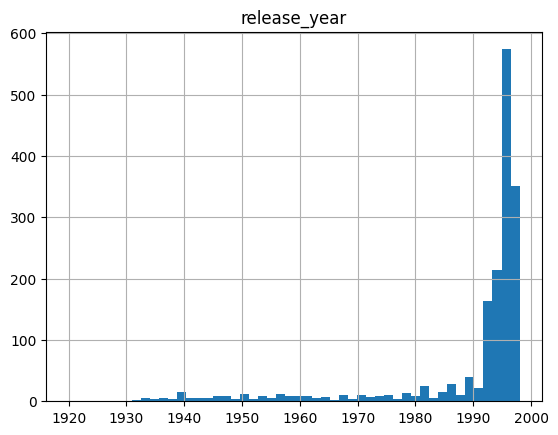

In [ ]:
items.hist('release_year',bins=50)

Let's further enrich the data by adding the popularity of each movie

In [ ]:
popularity = df.groupby('item_id').size().reset_index(name='popularity')
items = pd.merge(popularity, items)
items.head()

,item_id,popularity,title,release_date,video_release_date,imdb_url,release_year
0,1,452,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,1995
1,2,131,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,1995
2,3,90,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,1995
3,4,209,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,1995
4,5,86,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),1995


In [ ]:
all_ratings = pd.merge(items, df)
all_ratings.head()

,item_id,popularity,title,release_date,video_release_date,imdb_url,release_year,user_id,rating,timestamp
0,1,452,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,1995,308,4,887736532
1,1,452,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,1995,287,5,875334088
2,1,452,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,1995,148,4,877019411
3,1,452,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,1995,280,4,891700426
4,1,452,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,1995,66,3,883601324


Next, we would like to find out the movies with highest rating

In [ ]:
rating_movies = pd.DataFrame(all_ratings.groupby('title')['rating'].mean())
rating_movies.sort_values(by = 'rating',ascending=False).head(10)

,rating
title,
Aiqing wansui (1994),5.0
Someone Else's America (1995),5.0
Star Kid (1997),5.0
Entertaining Angels: The Dorothy Day Story (1996),5.0
"Saint of Fort Washington, The (1993)",5.0
Prefontaine (1997),5.0
"Great Day in Harlem, A (1994)",5.0
They Made Me a Criminal (1939),5.0
Marlene Dietrich: Shadow and Light (1996),5.0


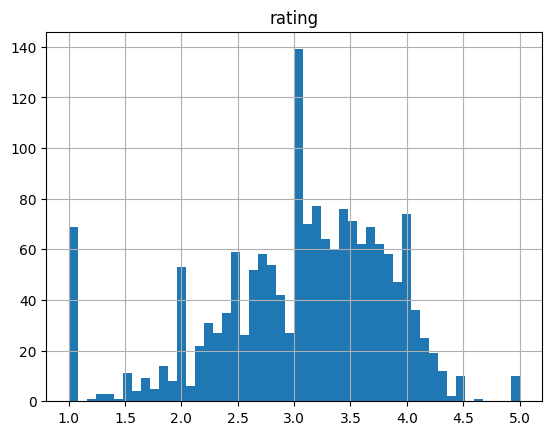

In [ ]:
rating_movies.hist(bins=50);

The peaks at 1 and 5, most likely, represent films that have been rated by only one or two people.

- If a single person gives a movie a "5," its average rating is 5.0.

- If a single person gives a movie a "1," its average rating is 1.0.

To double check this, we can add another column, showing the number of rating for a given movie

In [ ]:
rating_movies['num of ratings'] = all_ratings.groupby('title')['rating'].count()
rating_movies.sort_values(by='rating',ascending=False).head()

,rating,num of ratings
title,,
Aiqing wansui (1994),5.0,1
Someone Else's America (1995),5.0,1
Star Kid (1997),5.0,3
Entertaining Angels: The Dorothy Day Story (1996),5.0,1
"Saint of Fort Washington, The (1993)",5.0,2


- Top highly rated movies (perfect rating) have very few number of ratings ranging from 1 to 3.

In [ ]:
rating_movies.sort_values(by='num of ratings',ascending=False).head()

,rating,num of ratings
title,,
Star Wars (1977),4.358491,583
Contact (1997),3.803536,509
Fargo (1996),4.155512,508
Return of the Jedi (1983),4.007890,507
Liar Liar (1997),3.156701,485


- The ratings of movies that were rated by a large number of people tends to center towards the mean rating. Notice that none of them has a perfect rating which is more realistic as rarely will many people agree on the same rating.

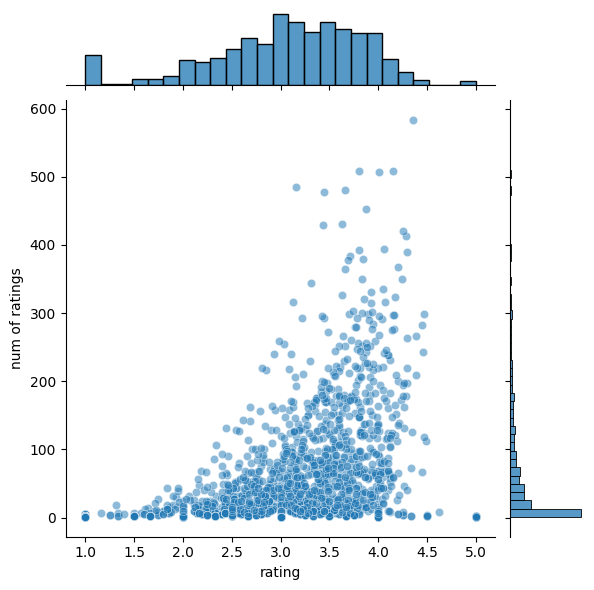

In [ ]:
import seaborn as sns
sns.jointplot(x='rating',y='num of ratings',data=rating_movies,alpha=0.5);

- Movies with an average rating of 1 or 5 have a small number of ratings
- Trend: films with a large number of ratings are globally highly rated films
- A frequently rated film cannot have a rating very close to 5

## 2. Evaluation of similarity between items
In this part, we set an item, say 'Star Wars (1977)'. We want to find films "similar" to Star Wars, and classify them in order of similarity, in order to recommend them.


In [ ]:
moviemat = pd.pivot_table(data=all_ratings,index='user_id',columns='title',values='rating')
moviemat.head()

title,'Til There Was You (1997),1-900 (1994),101 Dalmatians (1996),12 Angry Men (1957),187 (1997),2 Days in the Valley (1996),"20,000 Leagues Under the Sea (1954)",2001: A Space Odyssey (1968),3 Ninjas: High Noon At Mega Mountain (1998),"39 Steps, The (1935)",...,Yankee Zulu (1994),Year of the Horse (1997),You So Crazy (1994),Young Frankenstein (1974),Young Guns (1988),Young Guns II (1990),"Young Poisoner's Handbook, The (1995)",Zeus and Roxanne (1997),unknown,Á köldum klaka (Cold Fever) (1994)
user_id,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,2.0,5.0,NaN,NaN,3.0,4.0,NaN,NaN,...,NaN,NaN,NaN,5.0,3.0,NaN,NaN,NaN,4.0,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,2.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,...,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,4.0,NaN


In [ ]:
starwars_user_ratings = moviemat['Star Wars (1977)']
liarliar_user_ratings = moviemat['Liar Liar (1997)']
starwars_user_ratings.corr(liarliar_user_ratings)

np.float64(0.15029176850357892)

In [ ]:
moviemat.corrwith(starwars_user_ratings)

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


,0
title,
'Til There Was You (1997),0.872872
1-900 (1994),-0.645497
101 Dalmatians (1996),0.211132
12 Angry Men (1957),0.184289
187 (1997),0.027398
...,...
Young Guns II (1990),0.228615
"Young Poisoner's Handbook, The (1995)",-0.007374
Zeus and Roxanne (1997),0.818182


- The result above provides the Pearson correlation coefficient between the rating patterns of Star Wars and every other movie in dataset (moviemat).
- It measures how similar other movies are to Star Wars based on user preference. A score near 1.0 means users who liked Star Wars tended to give that movie a high rating too.

In [ ]:
similar_to_starwars = pd.DataFrame(moviemat.corrwith(starwars_user_ratings),columns=['Corr'])
similar_to_starwars.sort_values(by='Corr',ascending=False).head(10)

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


,Corr
title,
Hollow Reed (1996),1.0
Man of the Year (1995),1.0
No Escape (1994),1.0
Commandments (1997),1.0
Cosi (1996),1.0
Stripes (1981),1.0
Star Wars (1977),1.0
"Line King: Al Hirschfeld, The (1996)",1.0
"Scarlet Letter, The (1926)",1.0


- From the results, a bunch of movies seems to be perfectly correlated with the Star War; however, the problem is that the correlations are calculated on the non-NaN values

- If a movie received an r rating from a single user, and that user rated r starwars, the correlation is 1

- To avoid this, we will look for the correlation among the films with more than 100 ratings

In [ ]:
similar_to_starwars['num of ratings'] = rating_movies['num of ratings']
similar_to_starwars.head()

,Corr,num of ratings
title,,
'Til There Was You (1997),0.872872,9
1-900 (1994),-0.645497,5
101 Dalmatians (1996),0.211132,109
12 Angry Men (1957),0.184289,125
187 (1997),0.027398,41


Next, we pick a a sufficient number of rating so that we can retain movies that are significantly similar to the Star War

In [ ]:
most_similar_movies = similar_to_starwars[similar_to_starwars['num of ratings']>100]
most_similar_movies.sort_values(by='Corr',ascending=False,inplace=True)
most_similar_movies.head(10)

/tmp/ipykernel_11467/2003345406.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  most_similar_movies.sort_values(by='Corr',ascending=False,inplace=True)


,Corr,num of ratings
title,,
Star Wars (1977),1.000000,583
"Empire Strikes Back, The (1980)",0.747981,367
Return of the Jedi (1983),0.672556,507
Raiders of the Lost Ark (1981),0.536117,420
Austin Powers: International Man of Mystery (1997),0.377433,130
"Sting, The (1973)",0.367538,241
Indiana Jones and the Last Crusade (1989),0.350107,331
Pinocchio (1940),0.347868,101
"Frighteners, The (1996)",0.332729,115


In [ ]:
most_similar_movies.reset_index(inplace=True)
most_similar_movies.head(10)

,title,Corr,num of ratings
0,Star Wars (1977),1.000000,583
1,"Empire Strikes Back, The (1980)",0.747981,367
2,Return of the Jedi (1983),0.672556,507
3,Raiders of the Lost Ark (1981),0.536117,420
4,Austin Powers: International Man of Mystery (1...,0.377433,130
5,"Sting, The (1973)",0.367538,241
6,Indiana Jones and the Last Crusade (1989),0.350107,331
7,Pinocchio (1940),0.347868,101
8,"Frighteners, The (1996)",0.332729,115
9,L.A. Confidential (1997),0.319065,297


- The above list identifies the movies that are most similar to the Star Wars that we can recommend.
- This demonstrates that meaningful similarity only emerges when high correlation is backed by a significant number of data points.

## 3. Collaborative filtering

- In this section, we will utilize Collaborative Filtering, which is based on the assumption that users who agreed in the past will likely agree again in the future.

- If User A and User B both enjoyed the same five movies, the system assumes they share a common preference profile. Consequently, if User A likes a new movie that User B hasn't seen yet, the model can predict a high rating for User B with significant confidence.

- Precisely, we want to predict unobserved ratings from the n_user x n_items interaction matrix

In [ ]:
ratings = moviemat.fillna(0).values
ratings[:5,:5]

array([[0., 0., 2., 5., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 2.],
       [0., 0., 0., 0., 0.],
       [0., 0., 2., 0., 0.]])

Let's see how many ratings we have in the dataset

In [ ]:
(ratings>0).sum()/(ratings.shape[0] * ratings.shape[1])*100

np.float64(6.353304205073823)

- The percentage of approximately 6.35% indicates that the user-movie interaction matrix is highly sparse, which is typical for recommendation systems.
- It confirms that most users have only rated a small fraction of the total movie library.

We compute a similarity matrix $S=(S_{i,j})$ between users.
We consider the 'centered cosine similarity':
$$
S_{i,j} = \frac{\langle \bar r_i,\bar r_j\rangle}{\|\bar r_i\|\,\|\bar r_j\|}
$$
where $\bar r_i$ is the vector of user ratings $i$, recentered by the average of the ratings given by the user in question. The following function provides the similarity matrix.

In [ ]:
def phi(x):
    return np.maximum(x,0)

def similarity(ratings):

    # vector containing for each user the number of ratings given
    r_user = (ratings>0).sum(axis=1)

    # vector containing for each user the average of the ratings given
    m_user = np.divide(ratings.sum(axis=1) , r_user, where=r_user!=0)

    # Notes recentered by the average per user: each line i contains the vector \bar r_i
    ratings_ctr = ratings.T - ((ratings.T!=0) * m_user)
    ratings_ctr = ratings_ctr.T

    # Gram matrix containing inner products
    sim = ratings_ctr.dot(ratings_ctr.T)

    # Renormalization
    norms = np.array([np.sqrt(np.diagonal(sim))])
    sim = sim / norms / norms.T
    sim = phi(sim)

    return sim

### Prediction
We want to predict all the ratings for a user $u$, based on the ratings provided by users who are similar to them. A first approach consists of defining, for every item $i$:
$$
\hat r_{u,i} = \frac{\sum_{v} S_{u,v} r_{v,i}}{\sum_{v:r_{v,i}\neq 0} S_{u,v}}
$$
where the sum is restricted to users $v$ who have actually rated item $i$ i
<br>

We can assess the error using RMSE or MAE

### Train, Test Split


In [ ]:
from sklearn.model_selection import train_test_split

train_ratings, test_ratings = train_test_split(all_ratings, test_size=0.2, random_state=0)

user_id_train = train_ratings['user_id']
item_id_train = train_ratings['item_id']
rating_train = train_ratings['rating']

user_id_test = test_ratings['user_id']
item_id_test = test_ratings['item_id']
rating_test = test_ratings['rating']

We generate the train and the test rating matrices.

In [ ]:
from scipy.sparse import *
train = coo_matrix((rating_train.values,(user_id_train.values-1,item_id_train.values-1)),
                   shape=(n_user,n_item)).toarray()
test = coo_matrix((rating_test.values,(user_id_test.values-1,item_id_test.values-1)),
                   shape=(n_user,n_item)).toarray()

We are defining the functions necessary for prediction and evaluation.

In [ ]:
def predict_ratings(ratings,sim):

    wsum_sim = np.abs(sim).dot(ratings>0)
    return np.divide(sim.dot(ratings) , wsum_sim, where= wsum_sim!=0)

def rmse(ratings,pred):
    return np.sqrt(np.sum(((ratings - pred) * (ratings>0))**2) / np.sum(ratings>0))
def mae(ratings,pred):
    return np.sum(np.abs((ratings - pred) * (ratings>0))) / np.sum(ratings>0)


Next, we evaluate the similarity matrix on the train set, predict ratings,  and calculate the RMSE on the test set.


In [ ]:
sim = similarity(train)
pred_ratings = predict_ratings(train,sim)
rmse(test,pred_ratings),mae(test,pred_ratings)

(np.float64(1.0124277940990118), np.float64(0.802475136139638))

To understand how well our model is doing, we can compare with the following random predictor which just predicts the user's average rating

In [ ]:
av_ratings = train.sum(axis=1) / (train>0).sum(axis=1)
rmse(test,av_ratings.reshape(train.shape[0],1)),mae(test,av_ratings.reshape(train.shape[0],1))

(np.float64(1.0382364422597652), np.float64(0.8318637291484662))

We see that our collaborative recommender is slightly better than just guessing a user's average (with margin of 0.03 in RMSE).


- One problem with the above approach is that some users are likely to give ratings that are always quite high, or always quite low. There is therefore a bias relative to this user. One can imagine that the relative difference of the notes is more important than their absolute value.

- So we'll subtract each user's rating average before summing over all similar users, then we'll re-add the subtracted average at the end:
$$
\hat r_{u,i} = \bar r_u + \frac{\sum_{v} S_{u,v} (r_{v,i}- \bar r_v)}{\sum_{v}S_{u, v}1_{r_{v,i}>0}}
$$
where $\bar r_u$ is the average rating of user $u$.


In [ ]:
def predict_ratings_bias_sub(ratings,sim):

    r_user = (ratings>0).sum(axis=1)
    m_user = np.divide(ratings.sum(axis=1) , r_user, where=(r_user!=0))
    ratings_moyens = np.dot(m_user.reshape(len(m_user),1), np.ones((1,ratings.shape[1])))

    wsum_sim = np.abs(sim).dot(ratings>0)
    pred = ratings_moyens + np.divide(sim.dot(ratings-(ratings>0)*ratings_moyens),wsum_sim, where= wsum_sim!=0)

    return np.minimum(5,np.maximum(1,pred))

In [ ]:
sim = similarity(train)
pred_ratings = predict_ratings_bias_sub(train,sim)
rmse(test,pred_ratings),mae(test,pred_ratings)

(np.float64(0.9392384886230772), np.float64(0.7346557260167766))

- The RMSE dropped by 0.073 and the MAE dropped by 0.067 compared to the previous standard collaborative filtering model. This significant improvement can be attributed to the model's new ability to account for individual user rating scales, effectively neutralizing the noise caused by "harsh" versus "lenient" raters.

## 4. Matrix factorization approach
- Matrix Factorization represents every user and every movie as a set of hidden features (or embeddings). For example, these features might capture how much a user likes "Action" or how much "Sci-Fi" a movie contains. By multiplying these user and movie factors back together, the model can estimate a rating for any combination, effectively uncovering the hidden connections that drive our viewing choices.


In [ ]:
from keras.layers import Input, Embedding, Flatten, Dot
from keras.models import Model

In [ ]:
# For each sample we input the integer identifiers
# of a single user and a single item
user_id_input = Input(shape=[1],name='user')
item_id_input = Input(shape=[1], name='item')

embedding_size = 30
user_embedding = Embedding(output_dim=embedding_size, input_dim=n_user + 1,
                           input_length=1, name='user_embedding')(user_id_input)

item_embedding = Embedding(output_dim=embedding_size, input_dim=n_item + 1,
                           input_length=1, name='item_embedding')(item_id_input)

# reshape from shape: (batch_size, input_length, embedding_size)
# to shape: (batch_size, input_length * embedding_size) which is
# equal to shape: (batch_size, embedding_size)
user_vecs = Flatten()(user_embedding)
item_vecs = Flatten()(item_embedding)

y = Dot(axes=1)([user_vecs, item_vecs])

model = Model(inputs=[user_id_input, item_id_input], outputs=y)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
print(model.summary())

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 30)     │     28,320 │ user[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_embedding      │ (None, 1, 30)     │     50,490 │ item[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_6 (Flatten) │ (None, 30)        │          0 │ user_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_7 (Flatten) │ (None, 30)        │          0 │ item_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_1 (Dot)         │ (None, 1)         │          0 │ flatten_6[0][0],  │
│                     │                   │            │ flatten_7[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 78,810 (307.85 KB)

 Trainable params: 78,810 (307.85 KB)

 Non-trainable params: 0 (0.00 B)

None


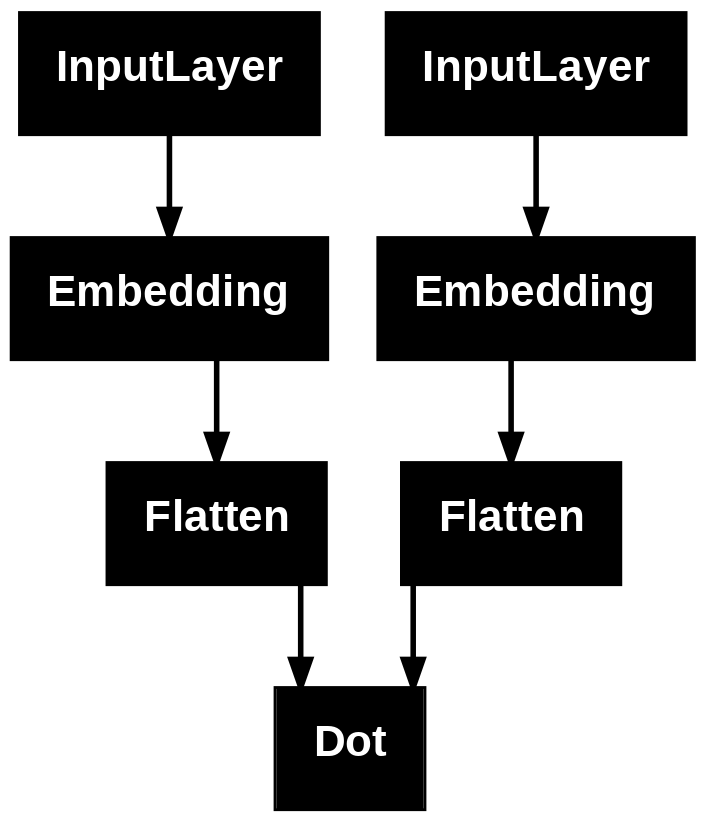

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(model, to_file='model.png')
from IPython.display import Image
Image(filename='model.png')

In [ ]:
model.compile(optimizer='adam', loss='mae')

In [ ]:
# Useful for debugging the output shape of model
initial_train_preds = model.predict([user_id_train, item_id_train])
initial_train_preds.shape

2500/2500 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


(80000, 1)

In [ ]:
model.save_weights('initial_weights.weights.h5')

### Model training


In [ ]:
%%time

# Training the model
history = model.fit([user_id_train, item_id_train], rating_train,
                    batch_size=64, epochs=20, validation_split=0.1,
                    shuffle=True)

Epoch 1/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 2.8657 - val_loss: 1.2989
Epoch 2/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.9595 - val_loss: 0.8350
Epoch 3/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.7811 - val_loss: 0.7835
Epoch 4/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7475 - val_loss: 0.7663
Epoch 5/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7344 - val_loss: 0.7566
Epoch 6/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7241 - val_loss: 0.7495
Epoch 7/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.7142 - val_loss: 0.7475
Epoch 8/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.7038 - val_loss: 0.7435
Epoch 9/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6943 - val_loss: 0.7387
Epoch 10/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6842 - val_loss: 0.7390
Epoch 11/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6749 - val_loss: 0.7345
Epoch 12/20
1125/1125 ━━━━━━━━

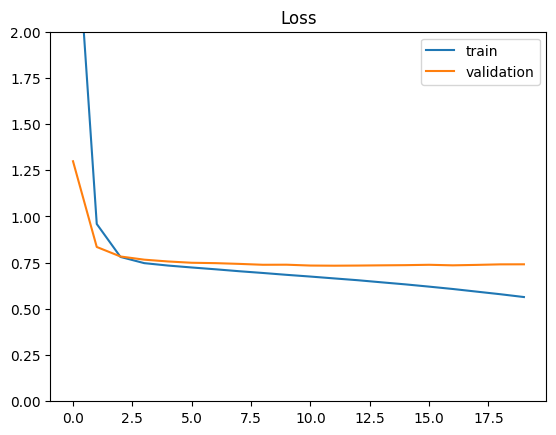

In [ ]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.ylim(0, 2)
plt.legend(loc='best')
plt.title('Loss');

- The model converges rapidly but begins to overfit after epoch 5, as shown by the widening gap between the improving training loss and the stagnating validation loss.

In [ ]:
test_preds = model.predict([user_id_test, item_id_test])
print("Final test MSE: %0.3f" % mean_squared_error(test_preds, rating_test))
print("Final test MAE: %0.3f" % mean_absolute_error(test_preds, rating_test))

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Final test MSE: 0.913
Final test MAE: 0.735



Next, We would like to reproduce the previous experiment by adding a stopping criterion when the validation loss increases.


In [ ]:
model.load_weights('initial_weights.weights.h5')

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 6 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=2)
model.fit([user_id_train, item_id_train], rating_train,
                    batch_size=64, epochs=20, validation_split=0.1,
                    callbacks=[early_stopping], shuffle=True)

Epoch 1/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 3.5286 - val_loss: 3.5280
Epoch 2/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3.5258 - val_loss: 3.5176
Epoch 3/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3.0775 - val_loss: 1.6407
Epoch 4/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.0360 - val_loss: 0.8424
Epoch 5/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.7824 - val_loss: 0.7836
Epoch 6/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.7446 - val_loss: 0.7644
Epoch 7/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7274 - val_loss: 0.7523
Epoch 8/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7132 - val_loss: 0.7467
Epoch 9/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7020 - val_loss: 0.7456
Epoch 10/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.6916 - val_loss: 0.7391
Epoch 11/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.6813 - val_loss: 0.7379
Epoch 12/20
1125/1125 ━━━━━━━━

In [ ]:
test_preds = model.predict([user_id_test, item_id_test])
print("Final test MSE: %0.3f" % mean_squared_error(test_preds, rating_test))
print("Final test MAE: %0.3f" % mean_absolute_error(test_preds, rating_test))

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Final test MSE: 0.908
Final test MAE: 0.733


- The MSE dropped to 0.897 and the MAE reached a new low of 0.727. This shows how the early stopping technique helped maintain the model at its best perfomance before it started overfitting.

## Deep recommender model

- While simple Matrix Factorization is effective at capturing linear relationships, it often misses the subtle, non-linear patterns hidden in user behavior. To bridge this gap, we move toward a Deep Learning Recommender architecture.

- Instead of just multiplying two vectors together, we feed our user and item embeddings into a series of Neural Network layers. These "Deep" layers act as a sophisticated pattern-recognition engine, allowing the model to learn complex interactions between users and movies that a simple mathematical dot product might overlook.


In [ ]:
from keras.layers import Concatenate, Dropout, Dense

In [ ]:
# Define input layers for user and item IDs (integers)
user_id_input = Input(shape=[1], name='user')
item_id_input = Input(shape=[1], name='item')

# Set the latent factor size;
embedding_size = 30

# Create Embeddings that map IDs to dense vectors
user_embedding = Embedding(output_dim=embedding_size, input_dim=n_user + 1,
                           input_length=1, name='user_embedding')(user_id_input)
item_embedding = Embedding(output_dim=embedding_size, input_dim=n_item + 1,
                           input_length=1, name='item_embedding')(item_id_input)

# Reshape the 3D embedding outputs into 2D vectors for the dense layers
user_vecs = Flatten()(user_embedding)
item_vecs = Flatten()(item_embedding)

# Concatenate the user and item vectors into one long feature vector
input_vecs = Concatenate()([user_vecs, item_vecs])

# Dropout: Randomly ignores 50% of neurons during training to prevent overfitting
input_vecs = Dropout(0.5)(input_vecs)

# Add ReLU allow the model to learn non-linear interactions between users and items
x = Dense(64, activation='relu')(input_vecs)

y = Dense(1)(x)

# Construct and compile the model using the Adam optimizer and Mean Absolute Error loss
model = Model(inputs=[user_id_input, item_id_input], outputs=y)
model.compile(optimizer='adam', loss='mae')

# Generate initial predictions on the training set using the untrained random weights
initial_train_preds = model.predict([user_id_train, item_id_train])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


2500/2500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


The following shows the structure of our network

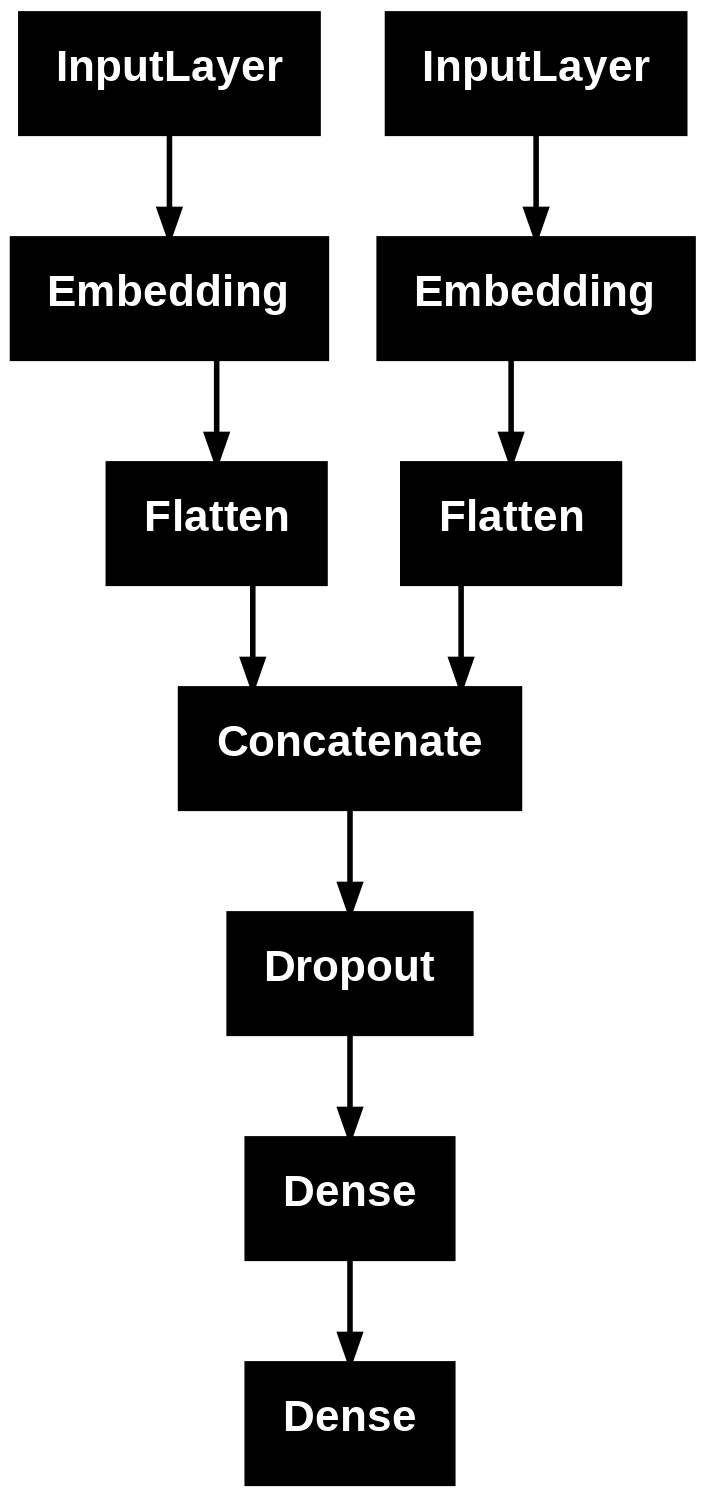

In [ ]:
plot_model(model, to_file='model.png')
Image(filename='model.png')

How many learnable parameters in the model?

In [ ]:
print(model.summary())

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 30)     │     28,320 │ user[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_embedding      │ (None, 1, 30)     │     50,490 │ item[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_8 (Flatten) │ (None, 30)        │          0 │ user_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_9 (Flatten) │ (None, 30)        │          0 │ item_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 60)        │          0 │ flatten_8[0][0],  │
│ (Concatenate)       │                   │            │ flatten_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 60)        │          0 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      3,904 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1)         │         65 │ dense_5[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 82,779 (323.36 KB)

 Trainable params: 82,779 (323.36 KB)

 Non-trainable params: 0 (0.00 B)

None


Next we train, and evaluate the model on test set

In [ ]:
%%time
history = model.fit([user_id_train, item_id_train], rating_train,
                    batch_size=64, epochs=20, validation_split=0.1,
                    callbacks = [early_stopping], shuffle=True)

Epoch 1/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.9942 - val_loss: 0.7552
Epoch 2/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.7548 - val_loss: 0.7448
CPU times: user 7.92 s, sys: 673 ms, total: 8.59 s
Wall time: 7.4 s


In [ ]:
test_preds = model.predict([user_id_test, item_id_test])
print("Final test MSE: %0.3f" % mean_squared_error(test_preds, rating_test))
print("Final test MAE: %0.3f" % mean_absolute_error(test_preds, rating_test))

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Final test MSE: 0.917
Final test MAE: 0.741


Next we experiment with additional layer, and embedding size to assess its impact on perfomance of the model

In [ ]:
embedding_size = 15  # Reduced from 30 to see if a tighter "bottleneck" generalizes better

# Embeddings and Flattening
user_embedding = Embedding(output_dim=embedding_size, input_dim=n_user + 1,
                           input_length=1)(user_id_input)
item_embedding = Embedding(output_dim=embedding_size, input_dim=n_item + 1,
                           input_length=1)(item_id_input)

user_vecs = Flatten()(user_embedding)
item_vecs = Flatten()(item_embedding)

# Architecture: Pyramid structure (widening then narrowing)
input_vecs = Concatenate()([user_vecs, item_vecs])

# Layer 1: Stronger processing, moderate Dropout
x = Dense(128, activation='relu')(input_vecs)
x = Dropout(0.3)(x) # Lowered from 0.5 to keep more "signal"

# Extra Layer: Added to find deeper relationships
x = Dense(64, activation='relu')(x)
x = Dropout(0.2)(x)

y = Dense(1)(x)

model_dense = Model(inputs=[user_id_input, item_id_input], outputs=y)
model_dense.compile(optimizer='adam', loss='mae', metrics=['mse'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


- Train the model

In [ ]:

# Stop if validation loss doesn't improve for 3 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Assuming 'early_stopping' is already defined as we discussed
history = model_dense.fit(
    [user_id_train, item_id_train],
    rating_train, # Corrected variable name
    batch_size=64,
    epochs=20,
    validation_split=0.1,
    callbacks=[early_stopping],
    shuffle=True
)

Epoch 1/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.9277 - mse: 1.4895 - val_loss: 0.7585 - val_mse: 0.9577
Epoch 2/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.7943 - mse: 1.0234 - val_loss: 0.7552 - val_mse: 0.9121


##  Adding metadata into the template

Using a framework similar to the one used previously, we will build another in-depth model that can also leverage additional metadata.

We want to add the columns ['popularity', 'release_year'] as input to our regressor, in addition to user_id and item_id. We pre-process these columns.

- We use QuantileTransformer which maps features to a uniform distribution to prevent high-magnitude values (like release years) from overwhelming the model's weights. This ensures all inputs are on a comparable scale, which stabilizes the training process and improves the neural network's convergence.

In [ ]:
from sklearn.preprocessing import QuantileTransformer

meta_columns = ['popularity', 'release_year']

scaler = QuantileTransformer()
item_meta_train = scaler.fit_transform(train_ratings[meta_columns])
item_meta_test = scaler.transform(test_ratings[meta_columns])

In [ ]:
user_id_input = Input(shape=[1], name='user')
item_id_input = Input(shape=[1], name='item')
meta_input = Input(shape=[2], name='meta_item')

embedding_size = 32
user_embedding = Embedding(output_dim=embedding_size, input_dim=n_user+1,
                           input_length=1, name='user_embedding')(user_id_input)
item_embedding = Embedding(output_dim=embedding_size, input_dim=n_item+1,
                           input_length=1, name='item_embedding')(item_id_input)

user_vecs = Flatten()(user_embedding)
item_vecs = Flatten()(item_embedding)

# The Concatenate layer now merges 3 sources: User, Item, and Metadata
input_vecs = Concatenate()([user_vecs, item_vecs, meta_input])

# --- Layer 1  ---
x = Dense(128, activation='relu')(input_vecs)
x = Dropout(0.5)(x)

# --- Layer 2  ---
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
# --- Layer 3  ---
x = Dense(32, activation='relu')(x)

# --- Layer 4  ---
x = Dense(16, activation='relu')(x)

# --- Final Output Layer ---
y = Dense(1)(x)

model = Model(inputs=[user_id_input, item_id_input, meta_input], outputs=y)
model.compile(optimizer='adam', loss='mae')

initial_train_preds = model.predict([user_id_train, item_id_train, item_meta_train])

2500/2500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step


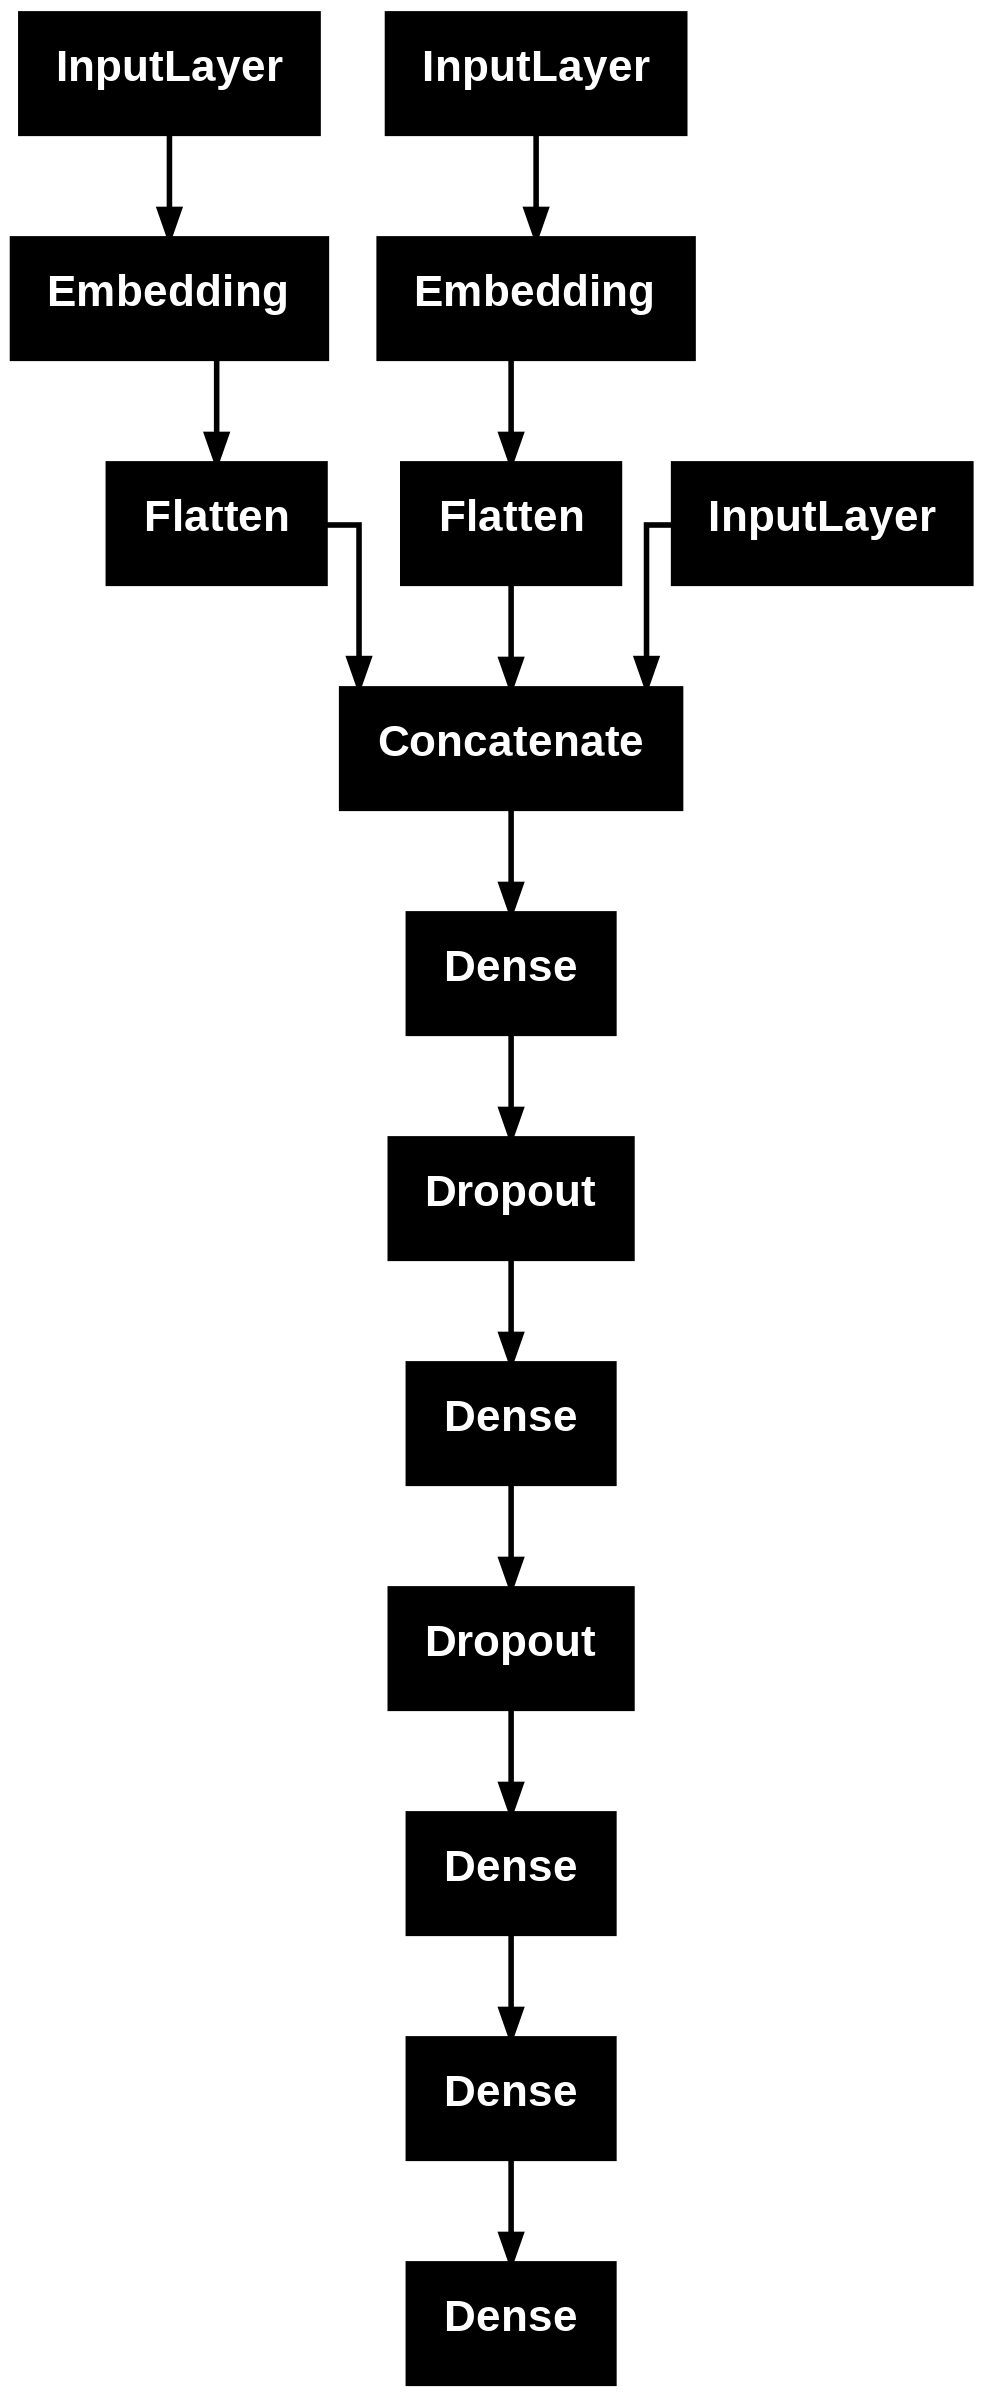

In [ ]:
plot_model(model, to_file='model.png')
Image(filename='model.png')

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit([user_id_train, item_id_train, item_meta_train], rating_train,
                    batch_size=64, epochs=20, validation_split=0.1,
                    callbacks = [early_stopping],shuffle=True)

Epoch 1/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.9106 - val_loss: 0.7807
Epoch 2/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.7561 - val_loss: 0.7762


In [ ]:
test_preds = model.predict([user_id_test, item_id_test, item_meta_test])
print("Final test MSE: %0.3f" % mean_squared_error(test_preds, rating_test))
print("Final test MAE: %0.3f" % mean_absolute_error(test_preds, rating_test))

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Final test MSE: 0.927
Final test MAE: 0.769


- The model’s higher MSE (0.927) compared to simpler Matrix Factorization suggests that the increased architectural complexity is likely capturing noise rather than meaningful patterns in this small dataset.

- While the MAE (0.733) remains competitive, the elevated MSE indicates that the neural network is prone to significant outliers that simple linear models avoid.

- Deep architectures and metadata integration typically require millions of samples to outperform linear baselines; without significantly more data, these extra layers introduce overfit rather than predictive power.